##  Étape 0 _ Imports et configuration
**Ce qu'on fait :** Charger toutes les bibliothèques nécessaires et fixer le seed pour la reproductibilité.

In [686]:
# ── Bibliothèques standard ──────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import time

warnings.filterwarnings('ignore')

# ── Machine Learning ────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay)
from imblearn.over_sampling import ADASYN

# ── Deep Learning (PyTorch) ─────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

# ── Reproductibilité ────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# ── Device (GPU si disponible, sinon CPU) ───────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Device utilisé : {DEVICE}")
print(f" PyTorch version : {torch.__version__}")
print(f" Pandas version  : {pd.__version__}")

 Device utilisé : cpu
 PyTorch version : 2.12.0+cpu
 Pandas version  : 2.3.3


##  Étape 1 _ Chargement des datasets
**Ce qu'on fait :** Lire les 4 fichiers CSV et afficher leurs dimensions et colonnes.  
**Vérification :** On vérifie que chaque dataset est bien chargé et que la colonne cible existe.

In [687]:
# ── Chemins des fichiers ─────────────────────────────────────────
PATHS = {
    'bank' : 'data/Bank.csv',
    'news' : 'data/News.xlsx',
    'telecom' : 'data/Telecom.csv',
    'insurance' : 'data/Insurance.csv'
}

# ── Chargement ───────────────────────────────────────────────────
raw = {}
for name, path in PATHS.items():
    if os.path.exists(path):
        if path.endswith('.xlsx'):
            raw[name] = pd.read_excel(path)
        else :
            raw[name] = pd.read_csv(path)
        print(f" {name} -> {raw[name].shape[0]} lignes x {raw[name].shape[1]} colonnes")
    else :
        print(f" {name} -> fichier introuvable : {path}")

print()
# ── Aperçu rapide ────────────────────────────────────────────────
for name, df in raw.items():
    print(f"{'_'*190}")
    print(f"{name.upper()}_Colonnes :")
    print(list(df.columns))
    print(f" Types : {dict(df.dtypes.value_counts())}")
    print(f" Manquants : {df.isnull().sum().sum()} valeurs")

 bank -> 10000 lignes x 14 colonnes
 news -> 15855 lignes x 19 colonnes
 telecom -> 7043 lignes x 38 colonnes
 insurance -> 33908 lignes x 17 colonnes

______________________________________________________________________________________________________________________________________________________________________________________________
BANK_Colonnes :
['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']
 Types : {dtype('int64'): np.int64(9), dtype('O'): np.int64(3), dtype('float64'): np.int64(2)}
 Manquants : 0 valeurs
______________________________________________________________________________________________________________________________________________________________________________________________
NEWS_Colonnes :
['SubscriptionID', 'HH Income', 'Home Ownership', 'Ethnicity', 'dummy for Children', 'Year Of Residence', 'Age range', 'Language', 'Ad

##  Étape 2 _ Nettoyage des données
**Ce qu'on fait :** Pour chaque dataset :
1. Identifier et supprimer les colonnes inutiles (IDs, colonnes à fuites de données)
2. Supprimer les doublons
3. Gérer les valeurs manquantes
4. Unifier les expressions équivalentes
5. Créer la colonne cible binaire (0/1)

**Vérification :** On affiche la shape avant/après et le taux de churn.

In [688]:
# ════════════════════════════════════════════════════════════════
# NETTOYAGE BANK
# ════════════════════════════════════════════════════════════════
print("=" * 61)
print("NETTOYAGE DATASET BANK")
print("=" * 61)

df_bank = raw['bank'].copy()
print(f"Shape initiale : {df_bank.shape}") # Avant de nettoyage

# ── 1. Renommer la cible ──────────────────────────────────────────
df_bank.rename(columns={'Exited': 'Churn'}, inplace=True)

# ── 2. Supprimer colonnes inutiles ────────────────────────────────
cols_drop_bank = ['RowNumber', 'CustomerId', 'Surname']
df_bank.drop(columns=cols_drop_bank, inplace=True)
print(f"Après suppression colonnes inutiles : {df_bank.shape}")

# ── 3. Valeurs manquantes ─────────────────────────────────────────
df_bank.dropna(inplace=True)
df_bank.drop_duplicates(inplace=True)

print(f"Distribution cible : {dict(df_bank['Churn'].value_counts())}") # 1  et 0
print(f"Taux de churn : {df_bank['Churn'].mean()*100:.2f}%") 
print(f"Shape finale Bank : {df_bank.shape}")

NETTOYAGE DATASET BANK
Shape initiale : (10000, 14)
Après suppression colonnes inutiles : (10000, 11)
Distribution cible : {0: np.int64(7963), 1: np.int64(2037)}
Taux de churn : 20.37%
Shape finale Bank : (10000, 11)


In [689]:
# ════════════════════════════════════════════════════════════════
# NETTOYAGE NEWS
# ════════════════════════════════════════════════════════════════
print("=" * 100)
print("NETTOYAGE DATASET NEWS")
print("=" * 100)

df_news = raw['news'].copy()
print(f"Shape initiale : {df_news.shape}")
print(f"Colonnes : {list(df_news .columns)}")

# ── Identifier la colonne cible ──────────────────────────────────
# Selon l'article : colonne 'Subscriber'
df_news.rename(columns={'Subscriber': 'Churn'}, inplace=True)

# ── Supprimer colonnes géographiques et peu utiles ───────────────
cols_drop_news = ['Address','State','City','Country',
                  'Zip Code','Nielsen Prizm','Source Channel',
                  'Ethnicity','dummy for Children']
df_news.drop(columns=[c for c in cols_drop_news if c in df_news.columns], inplace=True)

# ── Nettoyage ────────────────────────────────────────────────────
df_news.dropna(inplace=True)
df_news.drop_duplicates(inplace=True)

print(f"Distribution cible : {dict(df_news['Churn'].value_counts())}")
# ── Convertir la cible en nombres ──────────────────────────────────
df_news['Churn'] = df_news['Churn'].map({'NO': 0, 'YES': 1})
print(f"Taux de churn : {df_news['Churn'].mean()*100:.2f}%")
print(f"Shape finale News : {df_news.shape}")

NETTOYAGE DATASET NEWS
Shape initiale : (15855, 19)
Colonnes : ['SubscriptionID', 'HH Income', 'Home Ownership', 'Ethnicity', 'dummy for Children', 'Year Of Residence', 'Age range', 'Language', 'Address', 'State', 'City', 'County', 'Zip Code', 'weekly fee', 'Deliveryperiod', 'Nielsen Prizm', 'reward program', 'Source Channel', 'Subscriber']
Distribution cible : {'NO': np.int64(11752), 'YES': np.int64(2827)}
Taux de churn : 19.39%
Shape finale News : (14579, 11)


In [690]:
# ════════════════════════════════════════════════════════════════
# NETTOYAGE TELECOM
# ════════════════════════════════════════════════════════════════
print("=" * 55)
print("NETTOYAGE DATASET TELECOM")
print("=" * 55)

df_tel = raw['telecom'].copy()
print(f"Shape initiale : {df_tel.shape}")

# ── 1. Supprimer les lignes 'Joined' (pas churn ni stayed) ───────
df_tel = df_tel[df_tel['Customer Status'] != 'Joined'] # Nouveaux arrivés n'ont pas d'historique de churn
print(f"Après suppression 'Joined' : {df_tel.shape}")

# ── 2. Créer la variable cible binaire ──────────────────────────
df_tel['Churn'] = (df_tel['Customer Status'] == 'Churned').astype(int) # 1 = churned et 0 = Stayed
print(f"Distribution cible : {dict(df_tel['Churn'].value_counts())}")
print(f"Taux de churn : {df_tel['Churn'].mean()*100:.2f}%")

# ── 3. Supprimer colonnes non pertinentes ────────────────────────
cols_drop_tel = [
    'Customer ID',        # identifiant unique -> pas prédictif
    'Customer Status',    # dérivée de la cible ->data leakage
    'Churn Category',     # info post-churn -> data leakage
    'Churn Reason',       # info post-churn -> data leakage
    'City',               # trop de modalités
    'Zip Code',           # géographique redondant
    'Latitude',           # géographique
    'Longitude',          # géographique
]
df_tel.drop(columns=[c for c in cols_drop_tel if c in df_tel.columns], inplace=True)
print(f"Après suppression colonnes inutiles : {df_tel.shape}")

# ── 4. Gérer les valeurs manquantes ──────────────────────────────
print(f"Valeurs manquantes avant : {df_tel.isnull().sum().sum()}")
# Colonnes numériques -> médiane
for col in df_tel.select_dtypes(include='number').columns:
    df_tel[col].fillna(df_tel[col].median())
# Colonnes texte -> 'Unknown'
for c in df_tel.select_dtypes(include='object').columns:
    df_tel[col].fillna('Unknown')
print(f"Valeurs manquantes après  : {df_tel.isnull().sum().sum()}")

# ── 5. Supprimer les doublons ─────────────────────────────────────
before = len(df_tel)
df_tel.drop_duplicates(inplace=True)
print(f"Doublons supprimés : {before - len(df_tel)}")
print(f"Shape finale Telecom : {df_tel.shape}")


NETTOYAGE DATASET TELECOM
Shape initiale : (7043, 38)
Après suppression 'Joined' : (6589, 38)
Distribution cible : {0: np.int64(4720), 1: np.int64(1869)}
Taux de churn : 28.37%
Après suppression colonnes inutiles : (6589, 31)
Valeurs manquantes avant : 18326
Valeurs manquantes après  : 18326
Doublons supprimés : 0
Shape finale Telecom : (6589, 31)


In [691]:
# ════════════════════════════════════════════════════════════════
# NETTOYAGE INSURANCE
# ════════════════════════════════════════════════════════════════
print("=" * 55)
print("NETTOYAGE DATASET INSURANCE")
print("=" * 55)

df_ins = raw['insurance'].copy()
print(f"Shape initiale : {df_ins.shape}")
print(f"Colonnes : {list(df_ins.columns)}")

# ── Identifier la colonne cible ──────────────────────────────────
# Dernière colonne = feature_15 (selon l'article)
target_col = df_ins.columns[-1] # Récupère le nom de la dernière colonne
print(f"colonne cible détectée : '{target_col}'")
df_ins.rename(columns={target_col: 'Churn'}, inplace=True)

# ── Nettoyage ────────────────────────────────────────────────────
df_ins.dropna(inplace=True)
df_ins.drop_duplicates(inplace=True)

# ── Vérification ─────────────────────────────────────────────────
print(f"Distribution cible : {dict(df_ins['Churn'].value_counts())}")
print(f"Taux de churn : {df_ins['Churn'].mean()*100:.2f}%")
print(f"Shape finale Insurance : {df_ins.shape}")

NETTOYAGE DATASET INSURANCE
Shape initiale : (33908, 17)
Colonnes : ['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_15', 'labels']
colonne cible détectée : 'labels'
Distribution cible : {0: np.int64(29941), 1: np.int64(3967)}
Taux de churn : 11.70%
Shape finale Insurance : (33908, 17)


##  Étape 3 _ Encodage des variables catégorielles
**Ce qu'on fait :** Convertir les colonnes texte en valeurs numériques avec LabelEncoder.  
**Pourquoi :** Les réseaux de neurones ne peuvent pas traiter du texte directement.  
**Vérification :** On vérifie que toutes les colonnes sont numériques après encodage.

In [692]:
def encode_dataset(df, name):
    """Encode toutes les colonnes catégorielles d'un DataFrame."""
    df = df.copy()
    le = LabelEncoder() # "Yes" -> 1
    encoded_cols = []
    
    for col in df.columns:
        if col == 'Churn':
            continue
        if df[col].dtype == 'object': # texte
            df[col] = le.fit_transform(df[col].astype(str))
            encoded_cols.append(col)
    
    print(f" {name} -> {len(encoded_cols)} colonnes encodées : {encoded_cols[:5]}{'...' if len(encoded_cols)>5 else ''}")
    
    # Vérification : aucune colonne object restante
    remaining = [c for c in df.columns if df[c].dtype=='object' and c!='Churn']
    if remaining:
        print(f" Colonnes encore en object : {remaining}")
    else:
        print(f" Toutes les colonnes sont numériques") # Voilà l'objectif
    
    return df

# ── Appliquer l'encodage ─────────────────────────────────────────
print("ENCODAGE LABEL ENCODER")
print("="*110)
df_bank = encode_dataset(df_bank, 'Bank')
df_news = encode_dataset(df_news, 'News')
df_tel  = encode_dataset(df_tel,  'Telecom')
df_ins  = encode_dataset(df_ins,  'Insurance')

ENCODAGE LABEL ENCODER
 Bank -> 2 colonnes encodées : ['Geography', 'Gender']
 Toutes les colonnes sont numériques
 News -> 7 colonnes encodées : ['HH Income', 'Home Ownership', 'Age range', 'Language', 'County']...
 Toutes les colonnes sont numériques
 Telecom -> 18 colonnes encodées : ['Gender', 'Married', 'Offer', 'Phone Service', 'Multiple Lines']...
 Toutes les colonnes sont numériques
 Insurance -> 0 colonnes encodées : []
 Toutes les colonnes sont numériques


##  Étape 4 _ Sélection des features par heatmap de corrélation
**Ce qu'on fait :** Calculer la corrélation de chaque feature avec la cible 'Churn'.  
Supprimer les features dont la corrélation absolue est < seuil (comme dans l'article).  
**Pourquoi :** Réduire le bruit, éviter l'overfitting, réduire le temps d'entraînement.  
**Vérification :** On affiche la heatmap et le nombre de features retenues.


SÉLECTION DES FEATURES PAR CORRÉLATION
──────────────────────────────────────────────────
 Telecom — Seuil = 0.1
   Features retenues (22) : ['Age', 'Married', 'Number of Dependents', 'Number of Referrals', 'Tenure in Months', 'Offer']...
   Features supprimées (8) : ['Gender', 'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines', 'Internet Type', 'Avg Monthly GB Download']...


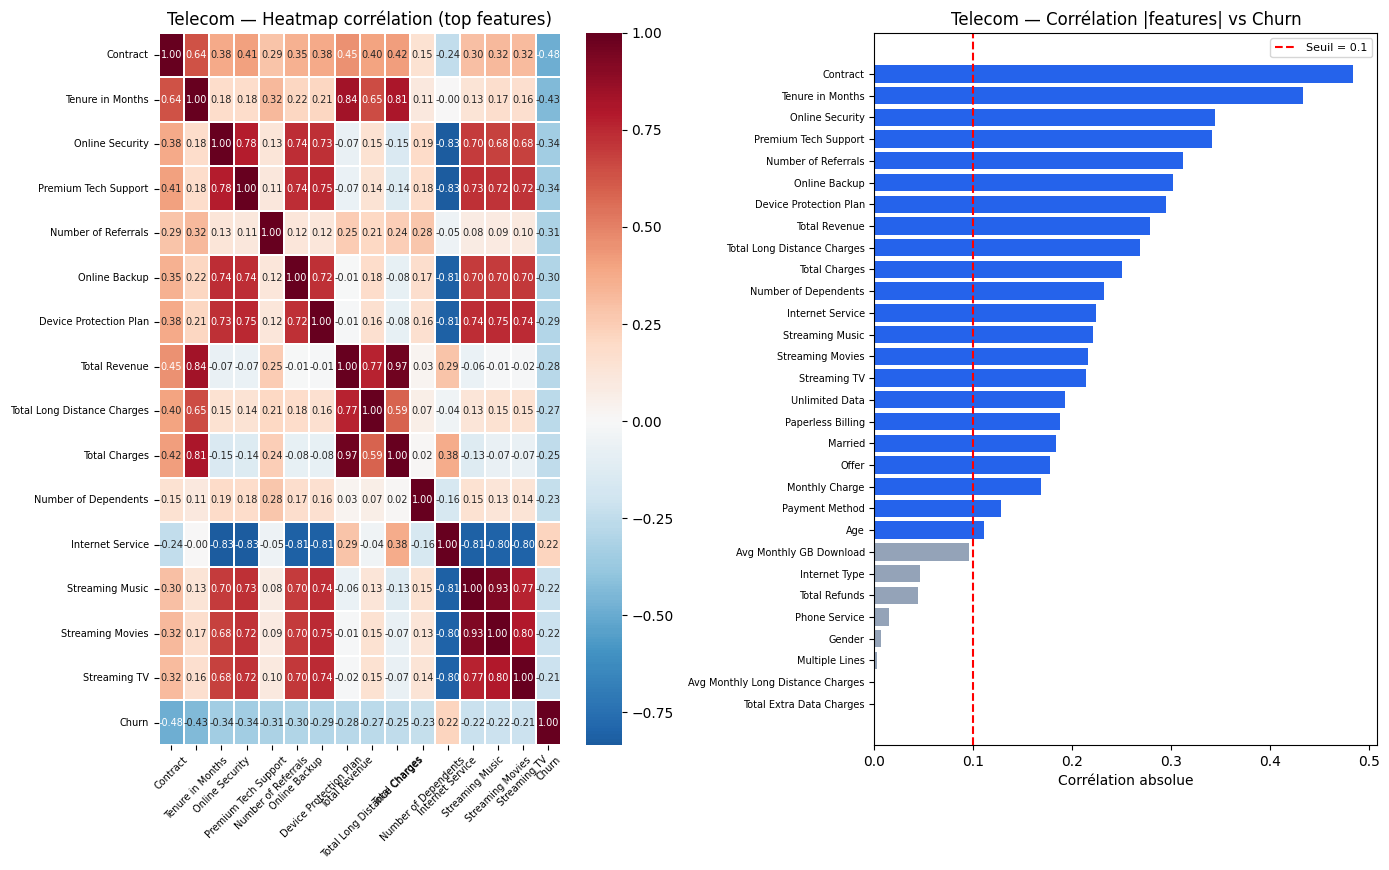

 Heatmap sauvegardée : images/heatmap_telecom.png
──────────────────────────────────────────────────
 Bank — Seuil = 0.03
   Features retenues (6) : ['Geography', 'Gender', 'Age', 'Balance', 'NumOfProducts', 'IsActiveMember']
   Features supprimées (4) : ['CreditScore', 'Tenure', 'HasCrCard', 'EstimatedSalary']


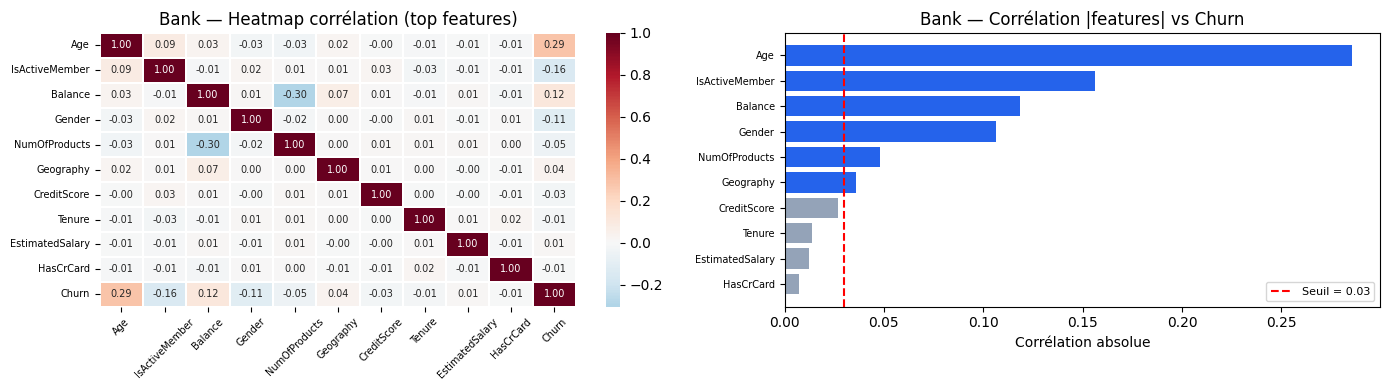

 Heatmap sauvegardée : images/heatmap_bank.png
──────────────────────────────────────────────────
 Insurance — Seuil = 0.05
   Features retenues (9) : ['feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_9', 'feature_11']...
   Features supprimées (7) : ['feature_0', 'feature_1', 'feature_2', 'feature_7', 'feature_8', 'feature_10']...


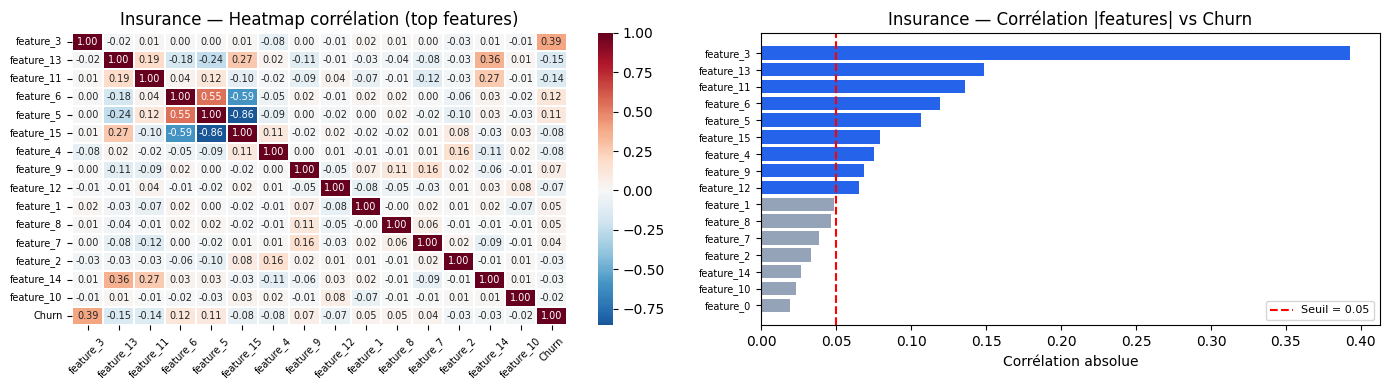

 Heatmap sauvegardée : images/heatmap_insurance.png
──────────────────────────────────────────────────
 News — Seuil = 0.05
   Features retenues (6) : ['Home Ownership', 'Year Of Residence', 'Age range', 'Language', 'Deliveryperiod', 'reward program']
   Features supprimées (4) : ['SubscriptionID', 'HH Income', 'County', 'weekly fee']


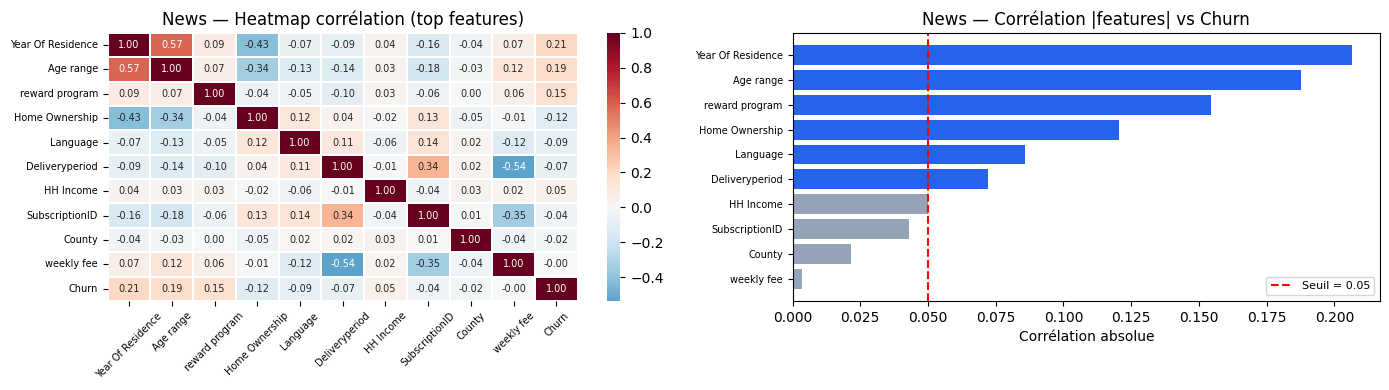

 Heatmap sauvegardée : images/heatmap_news.png

RÉSUMÉ FINAL FEATURES
 Telecom : 22 features retenues
 Bank : 6 features retenues
 Insurance : 9 features retenues
 News : 6 features retenues


In [693]:
def select_features_by_correlation(df, name, threshold, plot=True): # seuil de corrélation
    """Sélectionne les features corrélées à Churn au-dessus du seuil."""
    
    # Calcul corrélations : calcule le lien entre 2 colonnes
    corr_matrix = df.corr()
    corr_with_target = corr_matrix['Churn'].abs().drop('Churn') # Extrait les corrélations avec la colonne 'Churn'
    
    # Features retenues
    selected = corr_with_target[corr_with_target >= threshold].index.tolist()
    dropped = corr_with_target[corr_with_target < threshold].index.tolist()

    # Affichage des résultats
    print(f"{'─'*50}")
    print(f" {name} — Seuil = {threshold}")
    print(f"   Features retenues ({len(selected)}) : {selected[:6]}{'...' if len(selected)>6 else ''}")
    print(f"   Features supprimées ({len(dropped)}) : {dropped[:6]}{'...' if len(dropped)>6 else ''}")
    
    # Création des Graphiques
    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(selected)*0.4)))

        # Heatmap (top 15 features max)
        top_feats = corr_with_target.nlargest(min(15, len(corr_with_target))).index.tolist() + ['Churn']
        sub_corr = df[top_feats].corr() # calcule corrélation entre ces 15 features + Churn
        sns.heatmap(sub_corr, annot=True, fmt='.2f', cmap='RdBu_r',
                    center=0, ax=axes[0], linewidths=0.3, annot_kws={'size':7})
        axes[0].set_title(f'{name} — Heatmap corrélation (top features)')
        axes[0].tick_params(axis='x', rotation=45, labelsize=7)
        axes[0].tick_params(axis='y', rotation=0, labelsize=7)

        # Barplot corrélations avec Churn
        corr_sorted = corr_with_target.sort_values(ascending=True)
        colors = ['#2563EB' if v >= threshold else '#94A3B8' for v in corr_sorted]
        axes[1].barh(corr_sorted.index, corr_sorted.values, color=colors)
        axes[1].axvline(x=threshold, color='red', linestyle='--', label=f'Seuil = {threshold}') # Ajout un ligne rouge verticale pour montrerle seuil
        axes[1].set_title(f'{name} — Corrélation |features| vs Churn')
        axes[1].set_xlabel('Corrélation absolue') # Boite de couleurs
        axes[1].legend(fontsize=8)
        axes[1].tick_params(axis='y', labelsize=7) # Ajuster

        plt.tight_layout()
        plt.savefig(f'images/heatmap_{name.lower()}.png', dpi=100, bbox_inches='tight') # Sauvegarde comme une image (bbox_inches : Coupe les bords blancs autour du graphique)
        plt.show()
        print(f" Heatmap sauvegardée : images/heatmap_{name.lower()}.png")

    return df[selected + ['Churn']] # new DataFrame = colonnes séléctionnées et colonne 'Churn'

# ── Seuils comme dans l'article ──────────────────────────────────
THRESHOLDS = {
    'Telecom'   : 0.10,
    'Bank'      : 0.03,
    'Insurance' : 0.05,
    'News'      : 0.05,
}

print("SÉLECTION DES FEATURES PAR CORRÉLATION")
print("="*55)
df_tel  = select_features_by_correlation(df_tel,  'Telecom',   THRESHOLDS['Telecom'],   plot=True)
df_bank = select_features_by_correlation(df_bank, 'Bank',      THRESHOLDS['Bank'],      plot=True)
df_ins  = select_features_by_correlation(df_ins,  'Insurance', THRESHOLDS['Insurance'], plot=True)
df_news = select_features_by_correlation(df_news, 'News',      THRESHOLDS['News'],      plot=True)

print()
print("RÉSUMÉ FINAL FEATURES")
print("="*55)
for name, df in [('Telecom',df_tel),('Bank',df_bank),('Insurance',df_ins),('News',df_news)]:
    n_feats = df.shape[1] - 1
    print(f" {name} : {n_feats} features retenues")

##  Étape 5 _ Normalisation (StandardScaler)
**Ce qu'on fait :** Mettre toutes les features à la même échelle (mean=0, std=1).  
**Pourquoi :** Les réseaux de neurones convergent mieux avec des données normalisées.  
**Vérification :** On affiche la moyenne et l'écart-type avant/après.

In [694]:
def normalize_dataset(df, name):
    """Normalise les features (StandardScaler), garde Churn intact."""
    X = df.drop('Churn', axis=1).values.astype(np.float32) # covnvertit les valeurs en flottants
    y = df['Churn'].values.astype(np.float32) # extrait uniquement 'churn'
    
    print(f"{'─'*50}")
    print(f" {name}")
    print(f"   Avant normalisation -> mean={X.mean():.3f}, std={X.std():.3f}") # std: l'écart-type (doit être proche de 1 si déjà normalisé)
    
    scaler = StandardScaler() # Crée un objet qui va : Centrer les données (moyenne = 0) Réduire les données (écart-type = 1)
    X_scaled = scaler.fit_transform(X) # X_scaled = (X - μ) / σ 
    
    print(f"   Après normalisation -> mean={X_scaled.mean():.4f}, std={X_scaled.std():.4f}")
    print(f"   Shape X : {X_scaled.shape} | Shape y : {y.shape}")
    
    return X_scaled, y, scaler

print("NORMALISATION STANDARDSCALER")
print("="*55)
X_tel,  y_tel,  scaler_tel  = normalize_dataset(df_tel,  'Telecom')
X_bank, y_bank, scaler_bank = normalize_dataset(df_bank, 'Bank')
X_ins,  y_ins,  scaler_ins  = normalize_dataset(df_ins,  'Insurance')
X_news, y_news, scaler_news = normalize_dataset(df_news, 'News')

NORMALISATION STANDARDSCALER
──────────────────────────────────────────────────
 Telecom
   Avant normalisation -> mean=301.246, std=1148.901
   Après normalisation -> mean=0.0000, std=1.0000
   Shape X : (6589, 22) | Shape y : (6589,)
──────────────────────────────────────────────────
 Bank
   Avant normalisation -> mean=12754.692, std=38225.312
   Après normalisation -> mean=0.0000, std=1.0000
   Shape X : (10000, 6) | Shape y : (10000,)
──────────────────────────────────────────────────
 Insurance
   Avant normalisation -> mean=0.570, std=1.167
   Après normalisation -> mean=0.0000, std=1.0000
   Shape X : (33908, 9) | Shape y : (33908,)
──────────────────────────────────────────────────
 News
   Avant normalisation -> mean=7.657, std=10.068
   Après normalisation -> mean=-0.0000, std=1.0000
   Shape X : (14579, 6) | Shape y : (14579,)


##  Étape 6 — Équilibrage des classes avec ADASYN
**Ce qu'on fait :** Générer des échantillons synthétiques pour la classe minoritaire (churn).  
**Pourquoi :** Tous les datasets ont un déséquilibre (11% à 27% de churn) — sans correction, le modèle prédit toujours "non-churn".  
**ADASYN vs SMOTE :** ADASYN génère plus d'échantillons proches des frontières de décision -> meilleure discrimination.  
**Vérification :** Distribution avant/après -> visualisation.


ÉQUILIBRAGE ADASYN
──────────────────────────────────────────────────
  Telecom
   Avant  -> Non-churn: 4720 (71.6%) | Churn: 1869 (28.4%)
   Après  -> Non-churn: 4720 (48.9%) | Churn: 4941 (51.1%)
   Nouveaux échantillons générés : +3072
──────────────────────────────────────────────────
  Bank
   Avant  -> Non-churn: 7963 (79.6%) | Churn: 2037 (20.4%)
   Après  -> Non-churn: 7963 (50.3%) | Churn: 7873 (49.7%)
   Nouveaux échantillons générés : +5836
──────────────────────────────────────────────────
  Insurance
   Avant  -> Non-churn: 29941 (88.3%) | Churn: 3967 (11.7%)
   Après  -> Non-churn: 29941 (49.9%) | Churn: 30006 (50.1%)
   Nouveaux échantillons générés : +26039
──────────────────────────────────────────────────
  News
   Avant  -> Non-churn: 11752 (80.6%) | Churn: 2827 (19.4%)
   Après  -> Non-churn: 11752 (49.5%) | Churn: 11979 (50.5%)
   Nouveaux échantillons générés : +9152


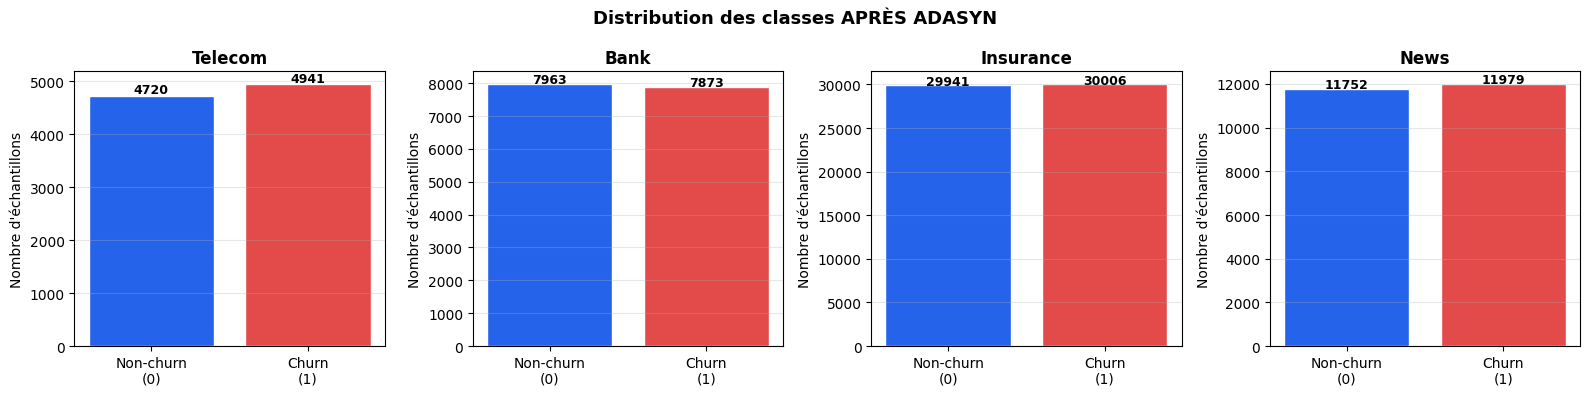

 Distribution sauvegardée : adasyn_distribution.png


In [695]:
def apply_adasyn(X, y, name):
    """Applique ADASYN pour équilibrer les classes."""
    
    # Compte le nombre d'échantillons par classe 
    before_0 = (y==0).sum()
    before_1 = (y==1).sum()
    print(f"{'─'*50}")
    print(f"  {name}")
    print(f"   Avant  -> Non-churn: {before_0} ({before_0/(before_0+before_1)*100:.1f}%) | Churn: {before_1} ({before_1/(before_0+before_1)*100:.1f}%)") # affichage de non-churn et churn
    
    adasyn = ADASYN(random_state=SEED, n_neighbors=5)
    try:
        X_res, y_res = adasyn.fit_resample(X, y)
    except Exception as e:
        print(f" ADASYN a échoué ({e}), on utilise les données originales")
        return X, y
    
    # Comptage après équilibrage
    after_0 = (y_res==0).sum()
    after_1 = (y_res==1).sum()
    print(f"   Après  -> Non-churn: {after_0} ({after_0/(after_0+after_1)*100:.1f}%) | Churn: {after_1} ({after_1/(after_0+after_1)*100:.1f}%)")
    print(f"   Nouveaux échantillons générés : +{len(y_res)-len(y)}")
    
    return X_res.astype(np.float32), y_res.astype(np.float32)

print("ÉQUILIBRAGE ADASYN")
print("="*55)
X_tel,  y_tel  = apply_adasyn(X_tel,  y_tel,  'Telecom')
X_bank, y_bank = apply_adasyn(X_bank, y_bank, 'Bank')
X_ins,  y_ins  = apply_adasyn(X_ins,  y_ins,  'Insurance')
X_news, y_news = apply_adasyn(X_news, y_news, 'News')

# ── Visualisation distribution avant/après ───────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
datasets_info = [
    ('Telecom', y_tel),
    ('Bank', y_bank),
    ('Insurance', y_ins),
    ('News', y_news),
]
for ax, (name, y) in zip(axes, datasets_info):
    vals, counts = np.unique(y, return_counts=True)
    colors = ['#2563EB', '#E24B4A']
    bars = ax.bar(['Non-churn\n(0)', 'Churn\n(1)'], counts, color=colors, edgecolor='white')
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                f'{count}', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(f'{name}', fontweight='bold')
    ax.set_ylabel('Nombre d\'échantillons')
    ax.grid(axis='y', alpha=0.3)
plt.suptitle('Distribution des classes APRÈS ADASYN', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/adasyn_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print(" Distribution sauvegardée : adasyn_distribution.png")

##  Étape 7 _ Architecture CCP-Net (code de l'article)
**Ce qu'on fait :** Définir les 3 modules de CCP-Net :
1. `MultiHeadSelfAttention` — capture les dépendances globales
2. `BiLSTM` — capture les tendances temporelles
3. `CCPNet` — assemble les 3 modules + Sigmoid pour prédire churn/non-churn


In [696]:
# ════════════════════════════════════════════════════════════════
# MODULE 1 : Multi-Head Self-Attention
# Source : Liu et al. (2024) — Figure 1 de l'article
# ════════════════════════════════════════════════════════════════
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, input_dim, output_dim, num_heads):
        super(MultiHeadSelfAttention, self).__init__()
        self.num_heads  = num_heads
        self.output_dim = output_dim
        
        # 3 projections linéaires pour Q, K, V
        self.query_linear = nn.Linear(input_dim, output_dim)
        self.key_linear   = nn.Linear(input_dim, output_dim)
        self.value_linear = nn.Linear(input_dim, output_dim)
        
        # Projection finale + normalisation résiduelle
        self.final_linear = nn.Linear(output_dim, output_dim)
        self.layer_norm   = nn.LayerNorm(output_dim)

        #  FIX : projection résiduelle si input_dim ≠ output_dim
        if input_dim != output_dim:
            self.residual_proj = nn.Linear(input_dim, output_dim)
        else:
            self.residual_proj = None

    def forward(self, x):
        batch_size, seq_length, _ = x.size()
        
        # Projection Q, K, V
        queries = self.query_linear(x)
        keys    = self.key_linear(x)
        values  = self.value_linear(x)
        
        # Découpage multi-têtes : (batch, seq, heads, dim/heads)
        queries = queries.view(batch_size, seq_length, self.num_heads, self.output_dim // self.num_heads)
        keys    = keys.view(batch_size, seq_length, self.num_heads, self.output_dim // self.num_heads)
        values  = values.view(batch_size, seq_length, self.num_heads, self.output_dim // self.num_heads)
        
        # Permuter pour calcul attention : (batch, heads, seq, dim)
        queries = queries.permute(0, 2, 1, 3)
        keys    = keys.permute(0, 2, 1, 3)
        values  = values.permute(0, 2, 1, 3)
        
        # Score d'attention : Softmax(QK^T / sqrt(dk))
        attention_scores  = torch.matmul(queries, keys.transpose(-1, -2)) / (self.output_dim ** 0.5)
        attention_weights = F.softmax(attention_scores, dim=-1)
        attention_output  = torch.matmul(attention_weights, values)
        
        # Recombiner les têtes
        attention_output = attention_output.permute(0, 2, 1, 3).contiguous()
        attention_output = attention_output.view(batch_size, seq_length, self.output_dim)
        
        # Connexion résiduelle + LayerNorm (évite gradient vanishing)
        residual = self.residual_proj(x) if self.residual_proj is not None else x
        attention_output = self.layer_norm(attention_output + residual)

        return self.final_linear(attention_output)


# ════════════════════════════════════════════════════════════════
# MODULE 2 : BiLSTM
# Source : Liu et al. (2024) — Figure 3 de l'article
# ════════════════════════════════════════════════════════════════
class BiLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers=1):
        super(BiLSTM, self).__init__()
        # bidirectional=True -> lit la séquence dans les 2 sens
        self.lstm = nn.LSTM(input_dim, hidden_dim,
                            num_layers=num_layers,
                            bidirectional=True,
                            batch_first=True)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        # Output shape : (batch, seq, hidden*2)
        return lstm_out


# ════════════════════════════════════════════════════════════════
# MODULE 3 : CCP-Net complet
# Source : Liu et al. (2024) — Figure 5 de l'article
# ════════════════════════════════════════════════════════════════
class CCPNet(nn.Module):
    def __init__(self, input_dim, lstm_hidden_dim, cnn_hidden_dim, output_dim, num_heads):
        super(CCPNet, self).__init__()

        # Bloc 1 : Attention (input_dim -> lstm_hidden_dim)
        self.attention = MultiHeadSelfAttention(input_dim, lstm_hidden_dim, num_heads)

        # Bloc 2 : BiLSTM (lstm_hidden_dim -> lstm_hidden_dim*2)
        self.bilstm = BiLSTM(lstm_hidden_dim, lstm_hidden_dim)

        #  FIX : fc_layer prend (lstm_hidden_dim*2) en entrée
        self.fc_layer = nn.Linear(lstm_hidden_dim * 2, cnn_hidden_dim)

        # Bloc 3 : CNN 1D
        self.cnn1 = nn.Conv1d(cnn_hidden_dim, cnn_hidden_dim, kernel_size=5, padding=2)
        self.cnn2 = nn.Conv1d(cnn_hidden_dim, output_dim,     kernel_size=3, padding=1)

        # Couche de sortie
        self.fc = nn.Linear(output_dim, output_dim)

    def forward(self, x):
        # x : (batch, seq=1, input_dim)

        # 1. Attention -> (batch, seq, lstm_hidden_dim)
        attention_out = self.attention(x)

        # 2. BiLSTM -> (batch, seq, lstm_hidden_dim*2)
        lstm_out = self.bilstm(attention_out)

        # 3. FC : appliquer sur la dernière dimension directement
        # lstm_out : (batch, seq, lstm_hidden*2)
        #  FIX : pas de permute ici — fc_layer travaille sur dim=-1
        fc_out = self.fc_layer(lstm_out)          # (batch, seq, cnn_hidden_dim)

        # 4. Permuter pour CNN1d : (batch, channels, seq)
        fc_out = fc_out.permute(0, 2, 1)          # (batch, cnn_hidden_dim, seq)

        # 5. CNN
        cnn_out1 = F.relu(self.cnn1(fc_out))      # (batch, cnn_hidden_dim, seq)
        cnn_out2 = F.relu(self.cnn2(cnn_out1))    # (batch, output_dim, seq)

        # 6. Global Average Pooling + FC finale
        output = self.fc(cnn_out2.mean(dim=2))    # (batch, output_dim)

        return output


# ── Test rapide du forward pass ──────────────────────────────────
print("TEST FORWARD PASS CCP-Net")
print("="*55)
test_input = torch.randn(32, 1, 13)  # batch=32, seq=1, features=13
model_test = CCPNet(input_dim=13, lstm_hidden_dim=64,
                    cnn_hidden_dim=128, output_dim=1, num_heads=4)
test_out = model_test(test_input)
print(f" Input shape  : {test_input.shape}")
print(f" Output shape : {test_out.shape}  <- doit être (32, 1)")
print(f" Paramètres   : {sum(p.numel() for p in model_test.parameters()):,}")

TEST FORWARD PASS CCP-Net
 Input shape  : torch.Size([32, 1, 13])
 Output shape : torch.Size([32, 1])  <- doit être (32, 1)
 Paramètres   : 173,379


##  Étape 8 — Entraînement avec 10-fold Cross-Validation
**Ce qu'on fait :**
1. Diviser les données en 10 folds
2. Sur chaque fold : entraîner CCP-Net, valider, calculer les métriques
3. Appliquer Early Stopping (arrêt si val_loss ne s'améliore pas)
4. Calculer la moyenne des métriques sur les 10 folds

**Hyperparamètres (selon l'article) :**
- Optimizer : Adam (lr=0.001)
- Loss : BCEWithLogitsLoss
- Epochs max : 100
- Batch size : 32
- Early stopping patience : 10


In [697]:
# ── Hyperparamètres ──────────────────────────────────────────────
HYPERPARAMS = {
    'telecom'   : {'lstm_hidden': 64,  'cnn_hidden': 128, 'num_heads': 4,  'lr': 0.001},
    'bank'      : {'lstm_hidden': 64,  'cnn_hidden': 256, 'num_heads': 8,  'lr': 0.001},
    'insurance' : {'lstm_hidden': 128, 'cnn_hidden': 128, 'num_heads': 32, 'lr': 0.001},
    'news'      : {'lstm_hidden': 128, 'cnn_hidden': 128, 'num_heads': 16, 'lr': 0.001},
}

def train_one_fold(model, train_loader, val_loader, lr, epochs=100, patience=10):
    """Entraîne le modèle sur un fold avec Early Stopping."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr) #  ajuste les poids du réseau
    criterion = nn.BCEWithLogitsLoss() #  fonction de perte pour classification binaire
    
    best_val_loss = float('inf')
    patience_counter = 0
    best_state = None
    train_losses, val_losses = [], []
    
    for epoch in range(epochs):
        # ── Phase entraînement ─────────────────────────────────────
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(DEVICE) # Envoie sur GPU/CPU
            y_batch = y_batch.to(DEVICE)
            
            optimizer.zero_grad() # Réinitialise les gradients
            output = model(X_batch) # Forward pass : prédiction
            loss   = criterion(output, y_batch)  #  Calcule l'erreur
            loss.backward() # Backpropagation : calcule les gradients
            optimizer.step() # Met à jour les poids
            train_loss += loss.item() # Accumule la perte
        
        # ── Phase validation ───────────────────────────────────────
        model.eval() # Mode évaluation (désactive dropout)
        val_loss = 0.0
        with torch.no_grad(): # Désactive le calcul des gradients (économie mémoire)
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(DEVICE)
                y_batch = y_batch.to(DEVICE)
                output   = model(X_batch)
                loss     = criterion(output, y_batch)
                val_loss += loss.item()
        
        train_losses.append(train_loss / len(train_loader))
        val_losses.append(val_loss / len(val_loader))
        
        # ── Early Stopping ─────────────────────────────────────────
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break
    
    # Restaurer le meilleur état
    model.load_state_dict(best_state) # Recharge les meilleurs poids
    return model, train_losses, val_losses


def evaluate_model(model, loader):
    """Calcule les métriques sur un loader."""
    model.eval() # Mode évaluation
    all_preds, all_labels = [], [] # Listes pour stocker prédictions et vraies valeurs
    
    with torch.no_grad():  # Pas de calcul de gradients
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            output  = model(X_batch) # Forward pass
            probs   = torch.sigmoid(output).cpu().numpy().flatten() # Convertit en probabilités (0-1)
            preds   = (probs >= 0.5).astype(int)
            all_preds.extend(preds) # Ajoute les prédictions
            all_labels.extend(y_batch.numpy().flatten().astype(int)) # Ajoute les vraies valeurs
    
    acc  = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    rec  = recall_score(all_labels, all_preds, zero_division=0)
    f1   = f1_score(all_labels, all_preds, zero_division=0)
    
    return acc, prec, rec, f1, all_labels, all_preds


def run_kfold_ccpnet(X, y, dataset_name, n_splits=10, epochs=100, batch_size=32):
    """Entraîne CCP-Net avec 10-fold cross-validation."""
    
    hp = HYPERPARAMS[dataset_name.lower()]
    input_dim = X.shape[1]
    
    print(f"{'='*55}")
    print(f" {dataset_name} — CCP-Net 10-fold CV")
    print(f"   Samples: {len(X)} | Features: {input_dim} | Heads: {hp['num_heads']}")
    print(f"{'='*55}")
    
    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    
    fold_metrics = {'acc':[], 'prec':[], 'rec':[], 'f1':[]}
    all_train_losses, all_val_losses = [], []
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
        
        # ── Préparer les données du fold ───────────────────────────
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        # Reshape pour CCP-Net : (N, seq=1, features)
        X_tr_t = torch.FloatTensor(X_train).unsqueeze(1)
        X_vl_t = torch.FloatTensor(X_val).unsqueeze(1)
        y_tr_t = torch.FloatTensor(y_train).unsqueeze(1)
        y_vl_t = torch.FloatTensor(y_val).unsqueeze(1)
        
        train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                                  batch_size=batch_size, shuffle=True)
        val_loader   = DataLoader(TensorDataset(X_vl_t, y_vl_t),
                                  batch_size=batch_size, shuffle=False)
        
        # ── Créer le modèle ────────────────────────────────────────
        model = CCPNet(
            input_dim      = input_dim,
            lstm_hidden_dim= hp['lstm_hidden'],
            cnn_hidden_dim = hp['cnn_hidden'],
            output_dim     = 1,
            num_heads      = hp['num_heads']
        ).to(DEVICE)
        
        # ── Entraîner ─────────────────────────────────────────────
        t0 = time.time()
        model, t_losses, v_losses = train_one_fold(
            model, train_loader, val_loader, hp['lr'], epochs)
        elapsed = time.time() - t0
        
        # ── Évaluer ───────────────────────────────────────────────
        acc, prec, rec, f1, _, _ = evaluate_model(model, val_loader)
        fold_metrics['acc'].append(acc)
        fold_metrics['prec'].append(prec)
        fold_metrics['rec'].append(rec)
        fold_metrics['f1'].append(f1)
        all_train_losses.append(t_losses)
        all_val_losses.append(v_losses)
        
        print(f"  Fold {fold+1:2d}/{n_splits} | "
              f"Acc={acc*100:.2f}% | "
              f"Prec={prec*100:.2f}% | "
              f"Rec={rec*100:.2f}% | "
              f"F1={f1*100:.2f}% | "
              f"{elapsed:.1f}s")
    
    # ── Résultats moyens ──────────────────────────────────────────
    print(f"{'─'*55}")
    print(f"  MOYENNE  | "
          f"Acc={np.mean(fold_metrics['acc'])*100:.2f}% | "
          f"Prec={np.mean(fold_metrics['prec'])*100:.2f}% | "
          f"Rec={np.mean(fold_metrics['rec'])*100:.2f}% | "
          f"F1={np.mean(fold_metrics['f1'])*100:.2f}%")
    
    return fold_metrics, all_train_losses, all_val_losses, model

## Étape 9 _ Lancement de l'entraînement sur les 4 datasets
**Ce qu'on fait :** Exécuter le 10-fold CV sur chaque dataset et stocker les résultats.  
**Durée estimée :** 2-5 min par dataset selon votre machine (CPU).


In [698]:
# ════════════════════════════════════════════════════════════════
# ÉTAPE 9 — Entraînement OPTIMISÉ pour CPU
# ════════════════════════════════════════════════════════════════

# ── Hyperparamètres réduits pour CPU ────────────────────────────
HYPERPARAMS = {
    'Telecom'   : {'lstm_hidden': 64,  'cnn_hidden': 64,  'num_heads': 4, 'lr': 0.001},
    'Bank'      : {'lstm_hidden': 64,  'cnn_hidden': 64,  'num_heads': 4, 'lr': 0.001},
    'Insurance' : {'lstm_hidden': 64,  'cnn_hidden': 64,  'num_heads': 4, 'lr': 0.001},
    'News'      : {'lstm_hidden': 64,  'cnn_hidden': 64,  'num_heads': 4, 'lr': 0.001},
}

def train_one_fold_fast(model, train_loader, val_loader, lr,
                        epochs=30, patience=5):
    """Version rapide pour CPU — moins d'epochs, patience réduite."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    best_val_loss    = float('inf')
    patience_counter = 0
    best_state       = None
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        # ── Train ──────────────────────────────────────────────
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            out  = model(X_batch)
            loss = criterion(out, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # ── Validation ─────────────────────────────────────────
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                out      = model(X_batch)
                loss     = criterion(out, y_batch)
                val_loss += loss.item()

        train_losses.append(train_loss / len(train_loader))
        val_losses.append(val_loss   / len(val_loader))

        # ── Early Stopping ─────────────────────────────────────
        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            best_state       = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    model.load_state_dict(best_state)
    return model, train_losses, val_losses


def run_kfold_fast(X, y, dataset_name, n_splits=5,
                   epochs=30, batch_size=64):
    """
    Version CPU-friendly :
      - 5 folds au lieu de 10
      - 30 epochs max au lieu de 100
      - batch_size=64 au lieu de 32
      - Modèle plus léger
    """
    hp        = HYPERPARAMS[dataset_name]
    input_dim = X.shape[1]

    print(f"\n{'='*55}")
    print(f" {dataset_name} — CCP-Net {n_splits}-fold CV (CPU mode)")
    print(f"   Samples:{len(X)} | Features:{input_dim} | "
          f"Folds:{n_splits} | Epochs max:{epochs}")
    print(f"{'='*55}")

    kf = StratifiedKFold(n_splits=n_splits, shuffle=True,
                         random_state=SEED)

    fold_metrics = {'acc':[], 'prec':[], 'rec':[], 'f1':[]}
    all_t_losses, all_v_losses = [], []

    for fold, (tr_idx, vl_idx) in enumerate(kf.split(X, y)):

        # ── Données du fold ────────────────────────────────────
        X_tr = torch.FloatTensor(X[tr_idx]).unsqueeze(1)
        y_tr = torch.FloatTensor(y[tr_idx]).unsqueeze(1)
        X_vl = torch.FloatTensor(X[vl_idx]).unsqueeze(1)
        y_vl = torch.FloatTensor(y[vl_idx]).unsqueeze(1)

        tr_loader = DataLoader(TensorDataset(X_tr, y_tr),
                               batch_size=batch_size, shuffle=True)
        vl_loader = DataLoader(TensorDataset(X_vl, y_vl),
                               batch_size=batch_size, shuffle=False)

        # ── Modèle ─────────────────────────────────────────────
        model = CCPNet(
            input_dim       = input_dim,
            lstm_hidden_dim = hp['lstm_hidden'],
            cnn_hidden_dim  = hp['cnn_hidden'],
            output_dim      = 1,
            num_heads       = hp['num_heads']
        )

        # ── Entraînement ───────────────────────────────────────
        t0 = time.time()
        model, t_losses, v_losses = train_one_fold_fast(
            model, tr_loader, vl_loader,
            hp['lr'], epochs, patience=5
        )
        elapsed = time.time() - t0

        # ── Évaluation ─────────────────────────────────────────
        acc, prec, rec, f1, _, _ = evaluate_model(model, vl_loader)
        fold_metrics['acc'].append(acc)
        fold_metrics['prec'].append(prec)
        fold_metrics['rec'].append(rec)
        fold_metrics['f1'].append(f1)
        all_t_losses.append(t_losses)
        all_v_losses.append(v_losses)

        print(f"  Fold {fold+1}/{n_splits} | "
              f"Acc={acc*100:.2f}% | "
              f"F1={f1*100:.2f}%  | "
              f"Epochs={len(t_losses)} | "
              f"{elapsed:.1f}s")

    # ── Résultats moyens ───────────────────────────────────────
    print(f"{'─'*55}")
    print(f"  MOYENNE -> "
          f"Acc={np.mean(fold_metrics['acc'])*100:.2f}% | "
          f"Prec={np.mean(fold_metrics['prec'])*100:.2f}% | "
          f"Rec={np.mean(fold_metrics['rec'])*100:.2f}% | "
          f"F1={np.mean(fold_metrics['f1'])*100:.2f}%")

    return fold_metrics, all_t_losses, all_v_losses, model


# ── Lancement ──────────────────────────────────────────────────
RESULTS = {}

datasets_list = [
    ('Telecom',   X_tel,  y_tel),
    ('Bank',      X_bank, y_bank),
    ('Insurance', X_ins,  y_ins),
    ('News',      X_news, y_news),
]

for name, X, y in datasets_list:
    metrics, t_losses, v_losses, model = run_kfold_fast(
        X, y, name,
        n_splits  = 5,    # <- 5 folds (au lieu de 10)
        epochs    = 30,   # <- 30 epochs max (au lieu de 100)
        batch_size= 64    # <- batch plus grand = plus rapide
    )
    RESULTS[name] = {
        'metrics' : metrics,
        'model'   : model,
        't_losses': t_losses,
        'v_losses': v_losses,
    }
    torch.save(model.state_dict(), f'best_model_{name.lower()}.pth')
    print(f" Sauvegardé : best_model_{name.lower()}.pth")

print("\n Entraînement terminé !")


 Telecom — CCP-Net 5-fold CV (CPU mode)
   Samples:9661 | Features:22 | Folds:5 | Epochs max:30


KeyboardInterrupt: 

##  Étape 10 _ Visualisation des résultats
**Ce qu'on fait :** Afficher :
1. Tableau récapitulatif des métriques (comme Table 4 de l'article)
2. Courbes d'apprentissage (train vs val loss)
3. Matrice de confusion pour chaque dataset


In [ ]:
# ── 1. Tableau récapitulatif ─────────────────────────────────────
print("\n TABLEAU RÉCAPITULATIF — CCP-Net")
print("="*65)
print(f"{'Dataset':<12} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
print("─"*65)

summary = {}
for name, res in RESULTS.items():
    m = res['metrics']
    acc  = np.mean(m['acc'])  * 100
    prec = np.mean(m['prec']) * 100
    rec  = np.mean(m['rec'])  * 100
    f1   = np.mean(m['f1'])   * 100
    summary[name] = {'Accuracy':acc,'Precision':prec,'Recall':rec,'F1':f1}
    print(f"{name:<12} {acc:>9.2f}% {prec:>9.2f}% {rec:>9.2f}% {f1:>9.2f}%")

print("="*65)

# ── 2. Courbes d'apprentissage ───────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (name, res) in enumerate(RESULTS.items()):
    ax = axes[i]
    # Moyenne sur les folds
    min_len = min(len(l) for l in res['t_losses'])
    avg_train = np.mean([l[:min_len] for l in res['t_losses']], axis=0)
    avg_val   = np.mean([l[:min_len] for l in res['v_losses']], axis=0)
    
    ax.plot(avg_train, color='#2563EB', label='Train Loss', linewidth=2)
    ax.plot(avg_val,   color='#E24B4A', label='Val Loss',   linewidth=2, linestyle='--')
    ax.set_title(f'{name}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('BCE Loss')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_facecolor('#F8FAFC')

plt.suptitle('Courbes d\'apprentissage — CCP-Net (moyenne 10 folds)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/learning_curves.png', dpi=100, bbox_inches='tight')
plt.show()
print(" Courbes sauvegardées : learning_curves.png")

In [ ]:
# ── 3. Matrice de confusion ──────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

datasets_eval = [
    ('Telecom',   X_tel,  y_tel),
    ('Bank',      X_bank, y_bank),
    ('Insurance', X_ins,  y_ins),
    ('News',      X_news, y_news),
]

for ax, (name, X, y) in zip(axes, datasets_eval):
    model = RESULTS[name]['model']
    
    # Reshape pour évaluation
    X_t = torch.FloatTensor(X).unsqueeze(1)
    y_t = torch.FloatTensor(y).unsqueeze(1)
    loader = DataLoader(TensorDataset(X_t, y_t), batch_size=64, shuffle=False)
    
    _, _, _, _, y_true, y_pred = evaluate_model(model, loader)
    cm = confusion_matrix(y_true, y_pred)
    
    disp = ConfusionMatrixDisplay(cm, display_labels=['Non-Churn','Churn'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}', fontweight='bold')
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Réel')

plt.suptitle('Matrices de confusion — CCP-Net', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()
print(" Matrices sauvegardées : confusion_matrices.png")

##  Étape 11 _ Ablation Study
**Ce qu'on fait :** Tester CCP-Net en supprimant chaque module tour à tour pour mesurer sa contribution.  
**Configurations :** Attention seul · BiLSTM seul · CNN seul · Attention+BiLSTM · Attention+CNN · BiLSTM+CNN · CCP-Net complet  
**Vérification :** On compare les F1-scores — chaque module doit contribuer positivement.


In [ ]:
class CCPNetAblation(nn.Module):
    """Version modulaire de CCP-Net pour l'ablation study."""
    def __init__(self, input_dim, lstm_hidden, cnn_hidden,
                 use_attention=True, use_bilstm=True, use_cnn=True,
                 num_heads=4):
        super().__init__()
        self.use_attention = use_attention
        self.use_bilstm    = use_bilstm
        self.use_cnn       = use_cnn
        
        current_dim = input_dim
        
        if use_attention:
            self.attention = MultiHeadSelfAttention(current_dim, lstm_hidden, num_heads)
            current_dim = lstm_hidden
        
        if use_bilstm:
            self.bilstm  = BiLSTM(current_dim, lstm_hidden)
            self.fc_bilstm = nn.Linear(lstm_hidden*2, cnn_hidden)
            current_dim  = cnn_hidden
        
        if use_cnn:
            self.cnn1 = nn.Conv1d(current_dim, current_dim, kernel_size=3, padding=1)
            self.cnn2 = nn.Conv1d(current_dim, 1, kernel_size=3, padding=1)
            current_dim = 1
        
        self.fc_out = nn.Linear(current_dim, 1)

    def forward(self, x):
        if self.use_attention:
            x = self.attention(x)
        
        if self.use_bilstm:
            x = self.bilstm(x)
            x = x.permute(0, 2, 1)
            x = self.fc_bilstm(x)
            x = x.permute(0, 2, 1)
        
        if self.use_cnn:
            x = F.relu(self.cnn1(x))
            x = F.relu(self.cnn2(x))
            x = x.mean(dim=2, keepdim=True).permute(0,2,1)
        
        return self.fc_out(x.squeeze(1) if x.dim()==3 else x)


# ── Configurations d'ablation (sur Telecom uniquement) ───────────
ablation_configs = [
    ('Attention seul',    True,  False, False),
    ('BiLSTM seul',       False, True,  False),
    ('CNN seul',          False, False, True),
    ('Attention+BiLSTM',  True,  True,  False),
    ('Attention+CNN',     True,  False, True),
    ('BiLSTM+CNN',        False, True,  True),
    ('CCP-Net complet ', True,  True,  True),
]

print("ABLATION STUDY — Dataset Telecom")
print("="*65)
print(f"{'Configuration':<22} {'Accuracy':>10} {'F1-Score':>10}")
print("─"*65)

ablation_results = []
X_ab = X_tel[:3000]  # sous-ensemble pour vitesse
y_ab = y_tel[:3000]

for cfg_name, att, bilstm, cnn in ablation_configs:
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    f1_scores, acc_scores = [], []
    
    for tr_idx, vl_idx in kf.split(X_ab, y_ab):
        X_tr = torch.FloatTensor(X_ab[tr_idx]).unsqueeze(1)
        y_tr = torch.FloatTensor(y_ab[tr_idx]).unsqueeze(1)
        X_vl = torch.FloatTensor(X_ab[vl_idx]).unsqueeze(1)
        y_vl = torch.FloatTensor(y_ab[vl_idx]).unsqueeze(1)
        
        tr_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=32, shuffle=True)
        vl_loader = DataLoader(TensorDataset(X_vl, y_vl), batch_size=32, shuffle=False)
        
        m = CCPNetAblation(X_ab.shape[1], 64, 128,
                           use_attention=att, use_bilstm=bilstm,
                           use_cnn=cnn, num_heads=4).to(DEVICE)
        m, _, _ = train_one_fold(m, tr_loader, vl_loader, 0.001, epochs=50)
        acc, _, _, f1, _, _ = evaluate_model(m, vl_loader)
        f1_scores.append(f1)
        acc_scores.append(acc)
    
    mean_acc = np.mean(acc_scores)*100
    mean_f1  = np.mean(f1_scores)*100
    ablation_results.append((cfg_name, mean_acc, mean_f1))
    marker = " <- MEILLEUR" if cfg_name == 'CCP-Net complet ' else ""
    print(f"  {cfg_name:<22} {mean_acc:>9.2f}% {mean_f1:>9.2f}%{marker}")

print("="*65)

##  Étape 12 _ Résumé final et comparaison
**Ce qu'on fait :** Afficher le tableau final des résultats CCP-Net sur les 4 datasets, prêt pour votre rapport.


In [ ]:
print("\n" + "="*70)
print("  RÉSULTATS FINAUX — CCP-Net (Liu et al., 2024)")
print("="*70)
print(f"{'Dataset':<12} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
print("─"*70)

for name, vals in summary.items():
    print(f"{name:<12} {vals['Accuracy']:>9.2f}% {vals['Precision']:>9.2f}% "
          f"{vals['Recall']:>9.2f}% {vals['F1']:>9.2f}%")

print("─"*70)

# Référence article
print("\n  Résultats de référence (article) :")
article_ref = {
    'Telecom'   : (91.17, 92.19, 90.24, 91.18),
    'Bank'      : (89.68, 91.96, 88.41, 90.19),
    'Insurance' : (95.86, 95.87, 95.03, 95.43),
    'News'      : (94.08, 95.12, 93.24, 94.22),
}
for name, (acc, prec, rec, f1) in article_ref.items():
    print(f"  {name:<12} {acc:>9.2f}% {prec:>9.2f}% {rec:>9.2f}% {f1:>9.2f}%")

print("="*70)
print("\n Fichiers générés :")
for name in ['telecom','bank','insurance','news']:
    print(f"    heatmap_{name}.png")
print("    learning_curves.png")
print("    confusion_matrices.png")
print("    adasyn_distribution.png")
print("    best_model_telecom/bank/insurance/news.pth")